In [1]:
import numpy as np
import matplotlib.pyplot as plt
from lmfit import Model

We will work backwards to find the total impedance of the DMRadio-50L circuit.
Let's use Roman's values. Below we set the frequency range for the analysis.

In [2]:
freq = np.linspace(249.e3, 250.e3, 100001)  # 250.e3
omega = 2*np.pi*freq

In [3]:
r_squid = 50  # assume large
m_in = 690e-12
z_in = 1/(1/(m_in * omega * 1j) + 1/r_squid)

r_wb = 0  # assume small
l_sq_tp = 609e-9
m_r = 50e-9

In [4]:
z_sq_tp = (l_sq_tp - m_r - m_in) * omega * 1j
z_r = m_r * omega * 1j

z_a = z_in + z_sq_tp + r_wb
z_b = 1 / (1/z_r + 1/z_a)

In [5]:
m_inj = 100e-9
l_res = 750e-6
c_res = 541.9e-12
r_ul = 0.572e-3
z_res = (l_res - m_inj - m_r) * omega * 1j + r_ul + 1 / (c_res * omega * 1j)

z_c = z_b + z_res
z_inj = m_inj * omega * 1j
z_d = 1 / (1/z_c + 1/z_inj)

In [6]:
r_sh = 1e-10  # small but arbitrary, Rb in original diagram
l_sh = 100e-6  # arbitrary

z_all = r_sh + (l_sh - m_inj) * omega * 1j + z_d

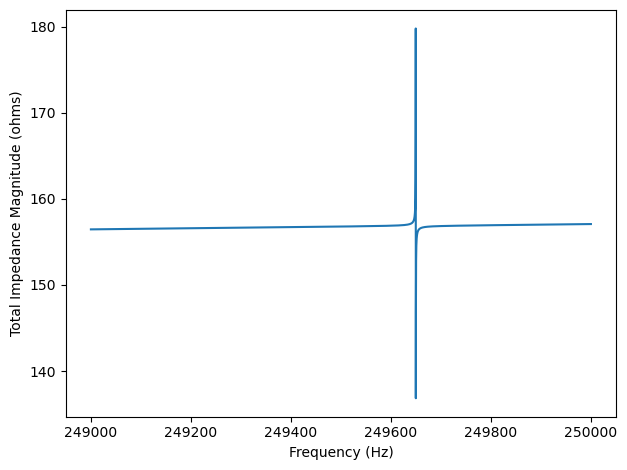

In [7]:
plt.plot(freq, np.abs(z_all))
plt.xlabel("Frequency (Hz)")
plt.ylabel("Total Impedance Magnitude (ohms)")
plt.tight_layout()
plt.show()

That's a weird graph! Let's look at the voltage at the SQUID input (AFTER mutual inductance from the tunable transformer), hopefully it looks more resonant. I also use a normalized 1 "volt" input.

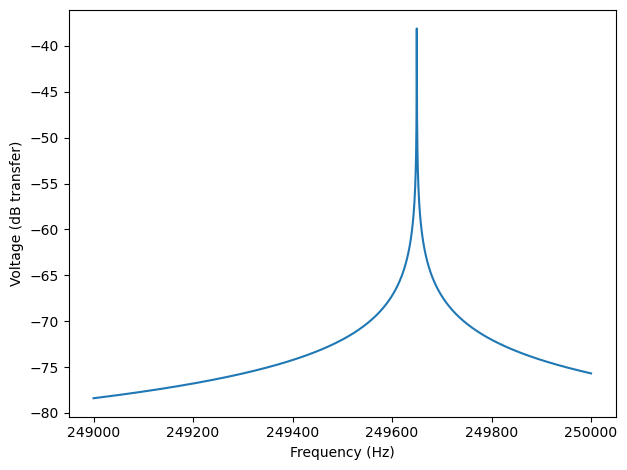

In [8]:
v_in = 1.  # normalized
v_zd = v_in * z_d / z_all
v_zb = v_zd * z_b / z_c
v_zin = v_zb * z_in / z_a

v_zin_abs = np.abs(v_zin)
v_zin_mag = np.max(v_zin_abs)

plt.plot(freq, np.log10(v_zin_abs)*10)
plt.xlabel("Frequency (Hz)")
plt.ylabel("Voltage (dB transfer)")
plt.tight_layout()
plt.show()

In [9]:
# voltage response fit
def lorentzian(x, par0, par1, par2):  # linear case, FOR VOLTAGE
    # par0: amplitude, par1: res freq, par2: bw
    return par0 / np.sqrt(1. + pow(((x - par1) / (par2 / 2.)), 2.))

lorentz_model = Model(lorentzian)

In [10]:
f0 = freq[np.argwhere(v_zin_abs == v_zin_mag)[0][0]]  # 249656.75  # 
q0 = 2.06e6

v_zin_fit = lorentz_model.fit(v_zin_abs, x=freq, par0=v_zin_mag, par1=f0, par2=f0/q0)
print(v_zin_fit.fit_report())
f0_fit = v_zin_fit.params["par1"].value
bw_fit = v_zin_fit.params["par2"].value
q0_fit = f0_fit / bw_fit

print(f"Quality Factor of Resonator: {q0_fit}")

[[Model]]
    Model(lorentzian)
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 9
    # data points      = 100001
    # variables        = 3
    chi-square         = 1.6359e-10
    reduced chi-square = 1.6359e-15
    Akaike info crit   = -3404690.29
    Bayesian info crit = -3404661.75
    R-squared          = 0.99964189
[[Variables]]
    par0:  1.5521e-04 +/- 1.8974e-08 (0.01%) (init = 0.0001550625)
    par1:  249649.750 +/- 1.5202e-04 (0.00%) (init = 249649.8)
    par2:  0.12157649 +/- 2.0749e-05 (0.02%) (init = 0.1211892)
[[Correlations]] (unreported correlations are < 0.100)
    C(par0, par2) = -0.7625
    C(par0, par1) = +0.5351
    C(par1, par2) = -0.1506
Quality Factor of Resonator: 2053437.7875312222


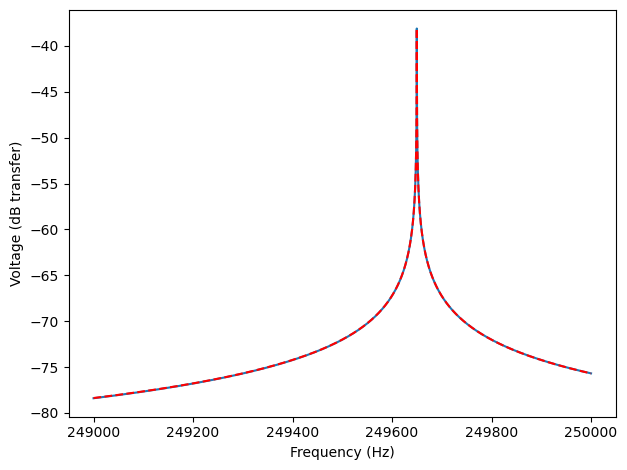

In [11]:
plt.plot(freq, np.log10(v_zin_abs)*10)
plt.plot(freq, np.log10(v_zin_fit.best_fit)*10, "r--")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Voltage (dB transfer)")
plt.tight_layout()
plt.show()

Let's do the same check for a broadband circuit. We just remove the capacitor.

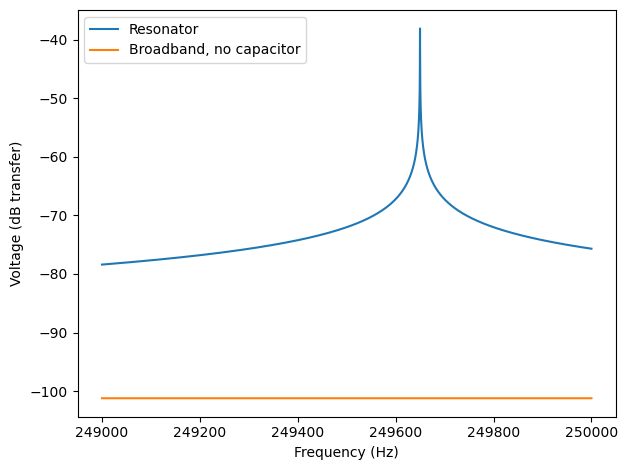

In [12]:
freq = np.linspace(249.e3, 250.e3, 100001)  # 250.e3
omega = 2*np.pi*freq
r_squid = 50  # assume large
m_in = 690e-12
z_in = 1/(1/(m_in * omega * 1j) + 1/r_squid)
r_wb = 0  # assume small
l_sq_tp = 609e-9
m_r = 50e-9
z_sq_tp = (l_sq_tp - m_r - m_in) * omega * 1j
z_r = m_r * omega * 1j
z_a = z_in + z_sq_tp + r_wb
z_b = 1 / (1/z_r + 1/z_a)
m_inj = 100e-9
l_res = 750e-6
r_ul = 0.572e-3
z_res = (l_res - m_inj - m_r) * omega * 1j + r_ul
z_c = z_b + z_res
z_inj = m_inj * omega * 1j
z_d = 1 / (1/z_c + 1/z_inj)
r_sh = 1e-10  # small but arbitrary, Rb in original diagram
l_sh = 100e-6  # arbitrary
z_all = r_sh + (l_sh - m_inj) * omega * 1j + z_d
v_in = 1.  # normalized
v_zd = v_in * z_d / z_all
v_zb = v_zd * z_b / z_c
# rename variables so we can compare
v_zin_bb = v_zb * z_in / z_a
v_zin_abs_bb = np.abs(v_zin_bb)
v_zin_mag_bb = np.max(v_zin_abs)

In [ ]:
plt.plot(freq, np.log10(v_zin_abs)*10, label="Resonator")
plt.plot(freq, np.log10(v_zin_abs_bb)*10, label="Broadband, no capacitor")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Voltage (dB transfer)")
plt.legend()
plt.tight_layout()
plt.show()